## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import psutil
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt
from skimage import morphology
import seaborn as sns
import pandas as pd
from aicsimageio import AICSImage

sys.path.append(os.path.relpath("../src"))
from CellAnalyzer import CellAnalyzer

29-May-26 09:09:28 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


## Initialize CellAnalyzer

In [2]:
in_path = r"C:\Users\roman\Documents\Data\vetsuisse_imaging_data\ALI_examples\Archive\test_set"

In [3]:
out_path = r"C:\Users\roman\Documents\Data\vetsuisse_imaging_data\ALI_test_set_NEW"

In [4]:
file_extension = ".nd2"
date_format = "%Y%m%d"
pattern = str(
r'(?P<prefix>[a-zA-Z0-9]+)_' +
r'(?P<condition>[a-zA-Z0-9]+)_'+
r'(?P<temp>[0-9]+)_'+
r'(?P<host>[a-zA-Z]+)_'+
r'(?P<donor>D\d+)_'+
r'(?P<mag>\d+x)_'+
r'(?P<time>\d+hpi)_'+
r'(?P<date>\d{8})_' +             # YYYYMMDD format
r'(?P<sample>\d+)\.nd2$')

In [5]:
ca = CellAnalyzer(path=in_path) # New instance
# ca = CellAnalyzer.load(out_path, load_images=False) # Load existing instance

>>> GPU activated? NO


## Read in and inspect data

In [6]:
df = ca.read_data(parsing_settings="custom", regex_pattern=pattern, file_extension=file_extension, date_format=date_format)

In [7]:
img_arrays = ca.load_images(num_imgs=4)

Loading 4 image(s). Status before this run: 0/4 loaded.
4 image(s) loaded. Status after this run: 4/4.


## Projections

In [8]:
types = ['max', 'max', 'max']#, 'max']  # Example projection types for each channel
proj = ca.create_projections(types=types) # gob, inf, ZO1, cil

Creating projections for 4 image(s). Status before this run: 0/4.
4 projection(s) created. Status after this run: 4/4.


In [9]:
display(ca.channels_df)
display(ca.samples_df)

,projection
0,max
1,max
2,max


,prefix,condition,temp,host,donor,mag,time,date,sample,replicate,sample_id,filename,filepath,is_loaded,has_projection,proj_mins,proj_maxs,proj_means
0,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True,True,"[116.0, 129.0, 120.0]","[4430.0, 23585.0, 65535.0]","[393.09604616518374, 737.878874225381, 224.244..."
1,v,229E,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,v_229E_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True,True,"[133.0, 137.0, 122.0]","[5150.0, 65535.0, 6414.0]","[399.4569882993345, 784.7449109112775, 235.810..."
2,m,mock,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,m_mock_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True,True,"[106.0, 136.0, 120.0]","[539.0, 13978.0, 10456.0]","[137.47294352967063, 987.9522352807315, 201.42..."
3,m,mock,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True,True,"[104.0, 127.0, 118.0]","[512.0, 18094.0, 3998.0]","[140.09278756600838, 422.12994554307727, 204.0..."


In [11]:
num_c = ca.projections[0].shape[0]
num_imgs = len(ca.projections)
display_range = (0, 1500)
print(f"Number of channels: {num_c}, Number of images: {num_imgs}")

Number of channels: 3, Number of images: 4


In [115]:
ca.subtract_background_on_projections(channels=[1], sigma=100, avg_imgs=True, overwrite=False, allow_partial_projections=False)

Channel 1: Using averaged blurred background (sigma=100).
Channel 1: Background subtraction applied to 4 projections (sigma=100, avg_imgs=True).
Background subtraction completed for requested channels [1].


Neither sigma/multiplier given, and avg_imgs=False: No background subtraction to perform.
Channel 1: Background subtraction applied to 4 projections (sigma=50, avg_imgs=False).
Background subtraction completed for requested channels [1].
Channel 1: Background subtraction applied to 4 projections (sigma=100, avg_imgs=False).
Background subtraction completed for requested channels [1].
Channel 1: Background subtraction applied to 4 projections (sigma=150, avg_imgs=False).
Background subtraction completed for requested channels [1].
No sigma and multiplier=None: proceeding without Gaussian blur (raw averages/subtraction).
Channel 1: No sigma and multiplier=None: proceeding without Gaussian blur (raw averages/subtraction).
Channel 1: Using raw average background (no Gaussian blur).
Channel 1: Background subtraction applied to 4 projections (sigma=None, avg_imgs=True).
Background subtraction completed for requested channels [1].
Channel 1: Using averaged blurred background (sigma=50).
Chann

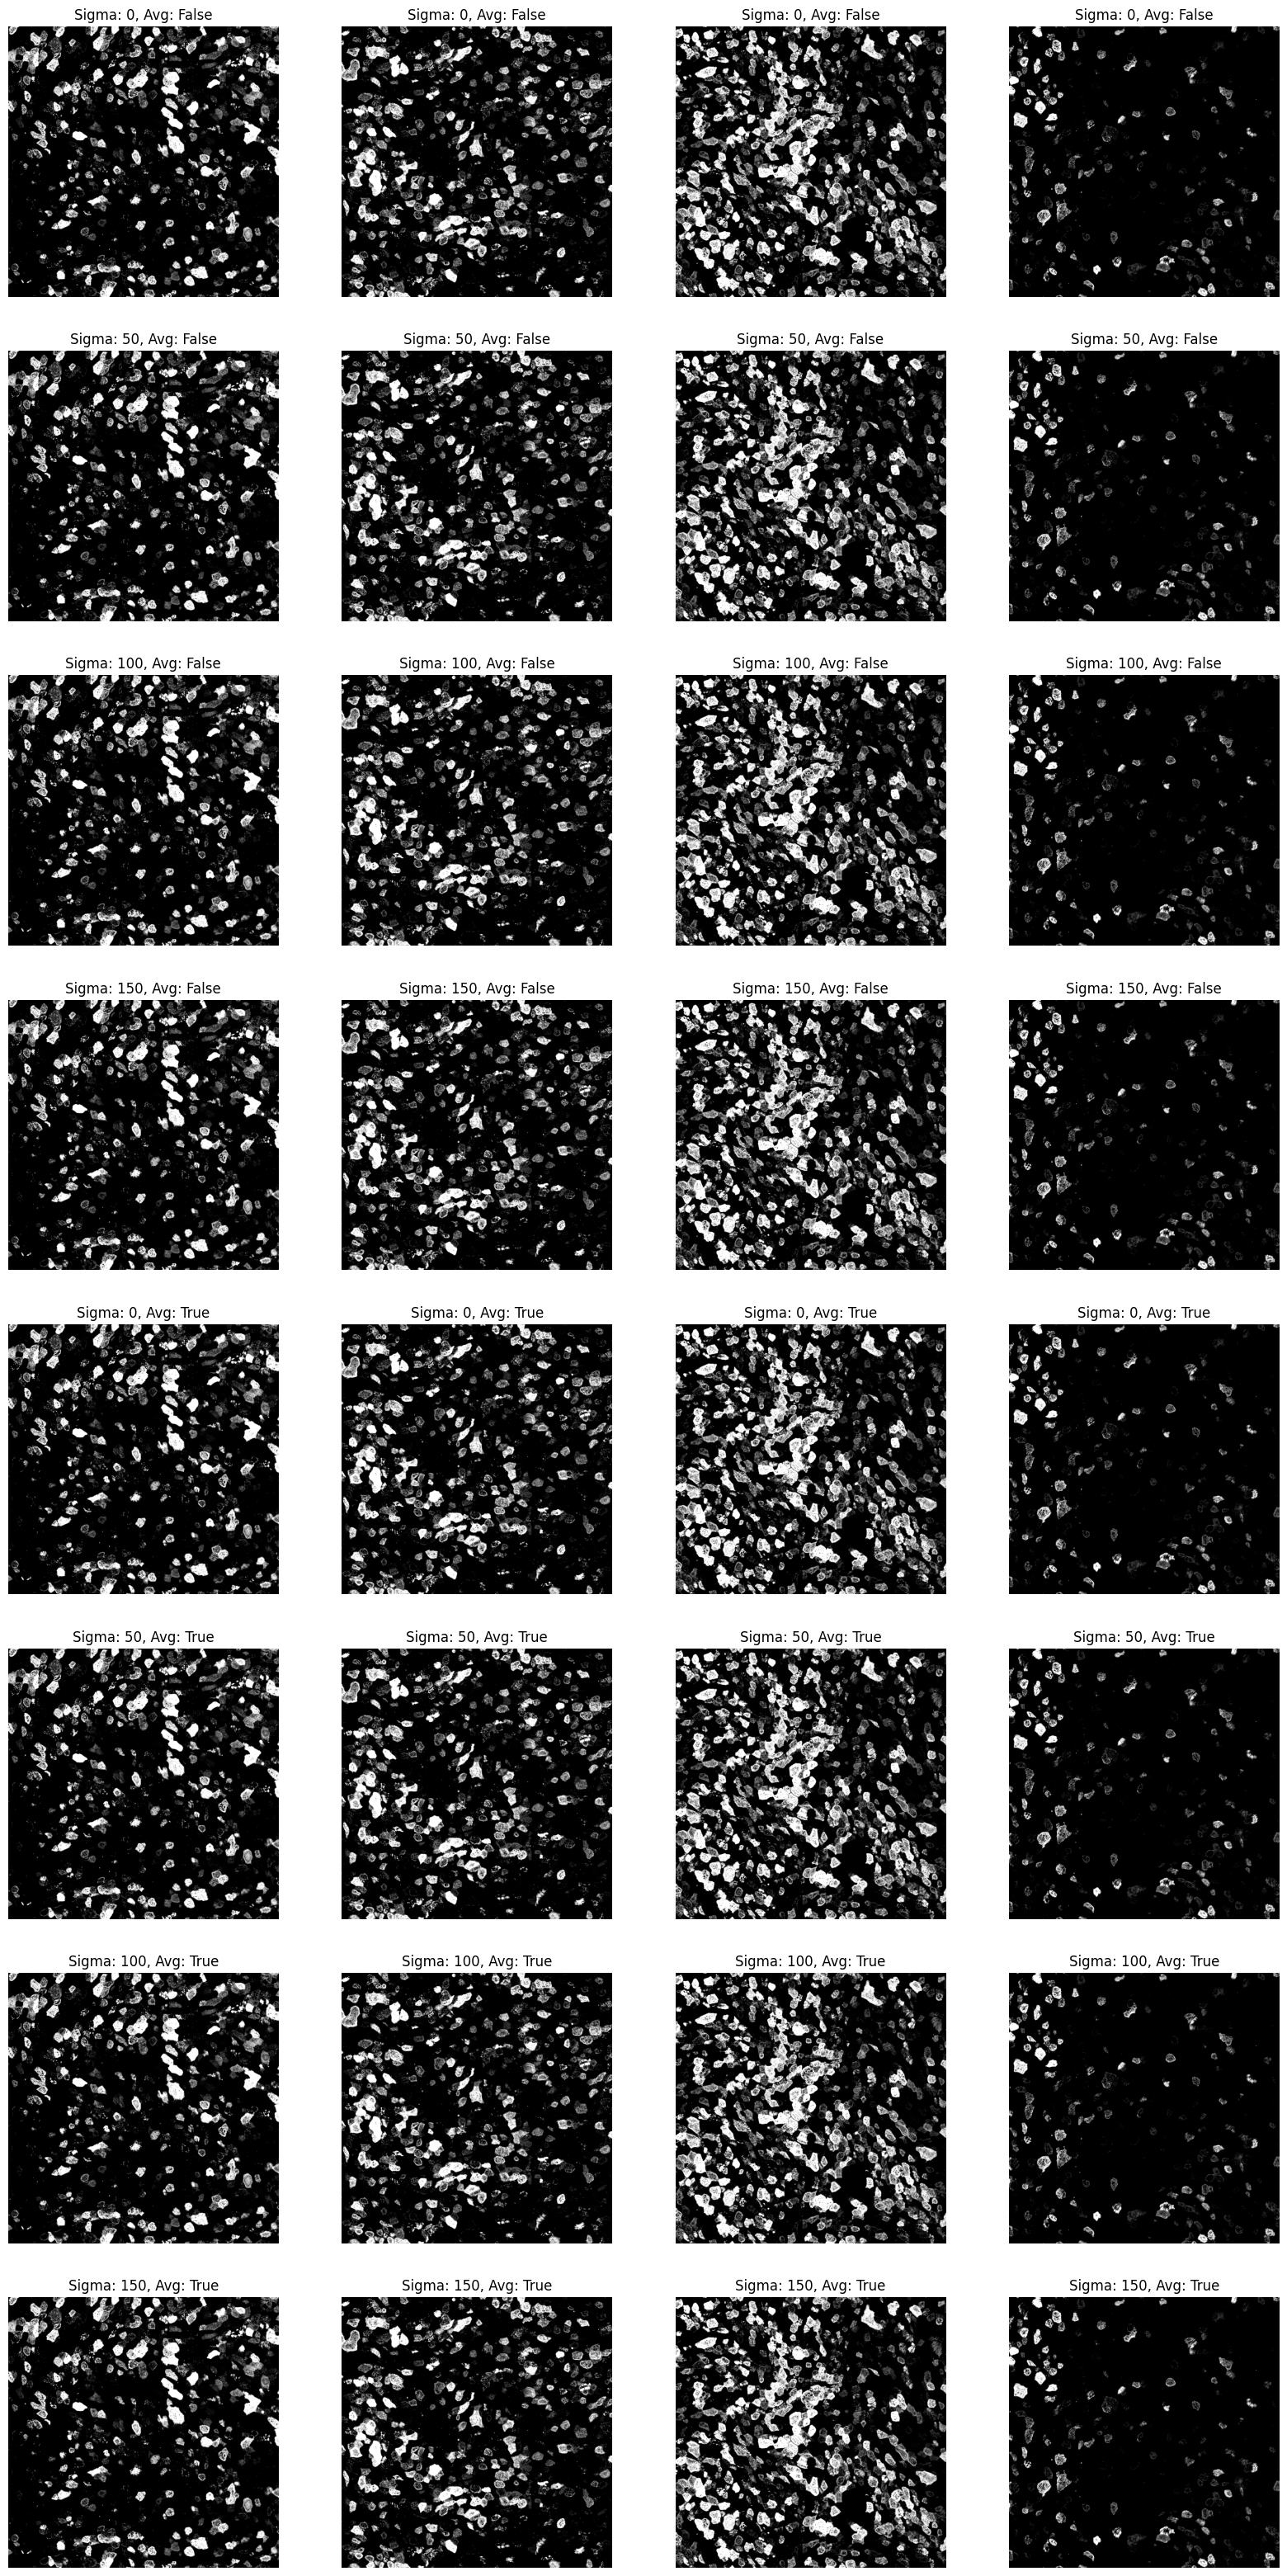

In [ ]:
num_proj = len([p for p in ca.projections if p is not None])
sigmas = [s for s in range(0, 200, 50)]
channel = 1

fig, ax = plt.subplots(2*len(sigmas), num_proj, figsize=(5*num_proj, 5*2*len(sigmas)))

for avg in [False, True]:
     for i, sigma in enumerate(sigmas):
        ca.subtract_background_on_projections(channels=[channel], sigma=sigma, avg_imgs=avg, multiplier=None, overwrite=True)
        for j in range(num_proj):
            im_ch = ca.projections[j][channel]
            row = avg * len(sigmas) + i
            ax[row, j].imshow(im_ch, cmap='gray', vmin=display_range[0], vmax=display_range[1])
            ax[row, j].set_title(f"Sigma: {sigma}, Avg: {avg}")
            ax[row, j].axis('off')